# Host-specific or just common words? — K2 evaluation demo

**K2 is a post-confirmation exploratory analysis. It ran on CPU only and cost $0.** A confirmed result says that a new concept takes up faster in a host subfield when its entry share there (`A_cont`) is higher. The question here is whether that effect is **host-specific** or simply reflects **generic accessibility**, meaning the concept's words are common everywhere.

Partner generality is measured two ways, both from the exact pre-entry profiles:
- **`G_H`**: the tag-weighted, normalised entropy of the concept's subfield distribution.
- **`G_F`**: the log block frequency.

The co-primary PPML fixed-effects model is re-fit in four variants:
- **M0**: `A_cont` alone.
- **M1**: `A_cont` plus the generality controls.
- **M2**: the lift `A_lift = ln(A_cont / s_dB)`.
- **M3**: `A_lift` plus the generality controls.

The key quantity is **retention = b(M1)/b(M0)**. The spec was frozen (sha256 `866c60a8…`) before any K2 coefficient was computed. The frozen decision rule is:
- **HOST-SPECIFIC** if the M3 `A_lift` CI lies above 1 **and** retention ≥ 0.5.
- **GENERIC** if retention < 0.5.
- **MIXED** otherwise.

**About the script.** The original `eval.py` is the final assembly step of the K2 pipeline. It reads the K2 result files (summary, power simulation, placebo host, audit, gates, descriptives, and the S2b diagnostic) and then does three things:
1. It draws figures F1–F3: the forest plot, retention with its design-analysis bands, and the within-FE scatter of generality.
2. It flattens every headline number into `metrics_agg`.
3. It writes `eval_out.json`, which has two datasets: the `k2_rows` coefficient table and the per-event `entry_generality` table.

It computes **no new coefficient**. The upstream fits (about 35 minutes of FE-PPML with 24,000 randomisation draws and 3,000 bootstrap draws) were run beforehand, and their outputs are bundled in `mini_demo_data.json`.

**About the demo data.** It holds every result file `eval.py` reads. The single curated dataset is **99 entry events (33 per fold)** from `partner_generality.parquet`. The full table has 5,086 events. Only the F3 scatter and the `entry_generality` dataset depend on this subset. Every metric and verdict comes from the complete result files.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This is the original import block. `matplotlib.use("Agg")` is commented out so that figures render inline in the notebook.

In [2]:
from __future__ import annotations

import json
import sys
import types
from pathlib import Path

import matplotlib

# matplotlib.use("Agg")  # original: headless backend; disabled so figures show inline in the notebook
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

## Load the bundled K2 result files
The data is fetched from GitHub, with a local `mini_demo_data.json` as the fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_MvbsSpVmwUlA/round-5/evaluation-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items()})

{'k2_summary': 8, 'k2_power': 4, 'k2_placebo_host': 6, 'audit_k2': 7, 'gates': 4, 'k2_descriptives': 3, 'k2_s2b_diagnostic': 3, 'k2_spec': 24, 'k2_rows': 123, 'partner_generality': 99}


## Config
`eval.py` has no iterations, epochs or samples of its own, because every coefficient was computed upstream. The only tunable knob here is how many of the bundled entry events per fold feed the F3 scatter and the `entry_generality` dataset. The bundle holds at most 33 per fold, and the original run used all 5,086 events: screen 1,740, held-out 1,097, MeSH 2,249.

In [5]:
N_PG_PER_FOLD = 33   # entry events per fold used from the curated subset (max 33 in the bundle; original: all 5,086 events)
FIG_DPI = 200        # original savefig dpi

## Setup: paths, logging and constants
This is the original setup block. `WS` is now the notebook's working directory, so figures and `eval_out.json` are written next to the notebook. The loguru file sink (`logs/eval.log`) is dropped, and only the stdout sink is kept. `FOLDS`, `FNAME` and `COL` are unchanged. `VCODE` maps each verdict to a number for `metrics_agg`.

In [6]:
WS = Path(".").resolve()  # original: Path(__file__).resolve().parent
RES, FIGS, AUD = WS / "results", WS / "figures", WS / "audit"
FIGS.mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")  # original file sink, not needed in the demo
FOLDS = ["screen", "heldout", "mesh"]
FNAME = {"screen": "Screen (main)", "heldout": "Held-out (main)", "mesh": "MeSH", "pooled": "IVW pooled"}
COL = {"screen": "#1f77b4", "heldout": "#ff7f0e", "mesh": "#2ca02c", "pooled": "#222222"}
VCODE = {"HOST-SPECIFIC": 1, "MIXED": 0, "GENERIC ACCESSIBILITY": -1, "NOT DETERMINED": np.nan}


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None

## F1: forest plot of the K2 coefficients
For each fold and for the IVW pool, this plots the IRR per SD with its 95% CI. The rows are:
- the focal term in M0 (`A_cont`), M1 (`A_cont | G`), M2 (`A_lift`) and M3 (`A_lift | G`);
- the two generality controls in M1 (`G_H` and `G_F`).

The fold CIs are CRV1 with t(G−1), and the pooled CI is IVW normal. `plt.show()` was added before `plt.close` so the figure displays.

In [7]:
def fig_forest(rows: pd.DataFrame) -> None:
    items = [("M0", "A_cont", "M0: A_cont"), ("M1", "A_cont", "M1: A_cont | G"), ("M2", "A_lift", "M2: A_lift"),
             ("M3", "A_lift", "M3: A_lift | G"), ("M1", "G_H", "M1: G_H"), ("M1", "G_F", "M1: G_F")]
    fig, ax = plt.subplots(figsize=(8, 7.5))
    yt, yl, y = [], [], 0
    for m, v, lab in items:
        for f in FOLDS + ["pooled_IVW"]:
            r = rows[(rows.fold == f) & (rows.model == m) & (rows["var"] == v)]
            if not len(r):
                continue
            r = r.iloc[0]
            key = "pooled" if f == "pooled_IVW" else f
            ax.errorbar(r.irr_sd, y, xerr=[[r.irr_sd - r.irr_sd_lo], [r.irr_sd_hi - r.irr_sd]], fmt="D" if key ==
                        "pooled" else "o", color=COL[key], ms=6 if key == "pooled" else 4, capsize=2)
            yt.append(y)
            yl.append(f"{lab}  [{FNAME[key]}]")
            y -= 1
        y -= 0.6
    ax.axvline(1, color="grey", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_yticks(yt)
    ax.set_yticklabels(yl, fontsize=7.5)
    ax.set_xlabel("IRR per SD (95% CI; CRV1 t(G-1) per fold, IVW normal pooled)")
    ax.set_title("K2: host share vs partner generality (co-primary FE, Y_strict)\nPOST-CONFIRMATION EXPLORATORY",
                 fontsize=10)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F1_k2_forest.{ext}", dpi=FIG_DPI)
    plt.show()  # added for the notebook
    plt.close(fig)

## F2: retention with the design-analysis bands
The point estimates are retention = b(M1)/b(M0), shown with their 95% concept-bootstrap CI. The shaded bars are the 2.5–97.5% range of retention across the Step-3 simulations, which were run before any K2 fit:
- **blue** bars simulate a host-specific data-generating process (DGP-S);
- **orange** bars simulate a generic one (DGP-G).

The red line marks the 0.5 decision threshold.

In [8]:
def fig_retention(summ: dict, power: dict) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    keys = FOLDS + ["pooled"]
    for i, k in enumerate(keys):
        d = summ["pooled"] if k == "pooled" else summ["folds"][k]
        pw = power["pooled"] if k == "pooled" else power["folds"][k]
        for dgp, off, c in (("DGP_S", -0.25, "#9ecae1"), ("DGP_G", 0.25, "#fdae6b")):
            q = (pw.get(dgp) or {}).get("ret_q025_q975")
            if q:
                ax.fill_between([i + off - 0.1, i + off + 0.1], q[0], q[1], color=c, alpha=0.8,
                                label=("simulated ret range, host-specific DGP" if dgp == "DGP_S" else
                                       "simulated ret range, generic DGP") if i == 0 else None)
        lo, hi = d["ret_ci"]
        ax.errorbar(i, d["ret"], yerr=[[d["ret"] - lo], [hi - d["ret"]]], fmt="D" if k == "pooled" else "o",
                    color=COL[k], capsize=4, ms=7)
        ax.text(i + 0.06, d["ret"], f"{d['ret']:.2f}", fontsize=8, va="bottom")
    ax.axhline(0.5, color="red", ls="--", lw=1, label="rule threshold 0.5")
    ax.axhline(1.0, color="grey", ls=":", lw=0.8)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([FNAME[k] for k in keys])
    ax.set_ylabel("retention b_A(M1) / b_A(M0)\n(95% concept-bootstrap CI)")
    ax.set_title("Share of the A_cont effect retained after partner-generality controls", fontsize=10)
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F2_retention.{ext}", dpi=FIG_DPI)
    plt.show()  # added for the notebook
    plt.close(fig)

## F3: host share against generality, after the fixed effects
`within()` projects `A_cont`, `G_H` and `G_F` off the concept, entry-year (`e`) and destination-subfield (`d`) fixed effects. It does this with the exact sparse-LU demeaning from the vendored PPML library (`d2/src/ppml.py`).

The original imported `ppml` from `d2/src`. Here `_demean` is copied verbatim and exposed as `ppml._demean`, so `within()` itself is unchanged. In the full data (5,086 events), the within-FE correlations are negative, with an R² of 3–16%. The demo subset has only 33 events per fold, selected so that about 16 residual degrees of freedom per fold survive the fixed effects. Its per-fold `r` values are therefore noisy and illustrative only.

In [9]:
# --- verbatim copy of d2/src/ppml.py::_demean (the original imported it via sys.path) ---
def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


ppml = types.SimpleNamespace(_demean=_demean)  # stands in for `import ppml`


def within(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    # sys.path.insert(0, str(WS / "d2" / "src"))  # original
    # import ppml                                  # original
    fes = [pd.factorize(df[c])[0] for c in ("concept_id", "e", "d")]
    return ppml._demean(df[cols].to_numpy(float), np.ones(len(df)), fes)


def fig_scatter(pg: pd.DataFrame) -> None:
    fig, axs = plt.subplots(1, 2, figsize=(9, 4))
    for f in FOLDS:
        d = pg[(pg.fold == f)].dropna(subset=["A_cont", "G_H", "G_F"])
        M = within(d, ["A_cont", "G_H", "G_F"])
        for j, (ax, g) in enumerate(zip(axs, ("G_H", "G_F"))):
            r = np.corrcoef(M[:, 0], M[:, j + 1])[0, 1]
            ax.scatter(M[:, j + 1], M[:, 0], s=4, alpha=0.35, color=COL[f], label=f"{FNAME[f]} (r={r:.2f})")
    for ax, g in zip(axs, ("G_H (normalised entropy)", "G_F (log block frequency)")):
        ax.set_xlabel(f"within-FE {g}")
        ax.set_ylabel("within-FE A_cont")
        ax.legend(fontsize=7, markerscale=3)
    fig.suptitle("Host share vs partner generality after concept + e + d FE (K2 input samples)", fontsize=10)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F3_generality_scatter.{ext}", dpi=FIG_DPI)
    plt.show()  # added for the notebook
    plt.close(fig)

## Flatten the headline numbers into `metrics_agg`
`metrics()` walks the summary, power, placebo, audit, gates and descriptives objects and emits one flat float per metric. This covers:
- retention and lift retention, per fold and pooled;
- verdict codes;
- IRR/SD with its CI and CRV1, wild, placebo-calibrated, randomisation and Holm p-values;
- gate A/B diffs;
- design-analysis probabilities;
- within-FE correlations;
- the S10 placebo host, the S1–S7 supplementary retentions, audit pass flags, and the post-hoc S2b diagnostic.

The only change from the original is that the S2b diagnostic is read from `data` instead of `results/k2_s2b_diagnostic.json`.

In [10]:
def metrics(summ, power, plc, aud, gates, desc) -> dict:
    m = {}
    P = summ["pooled"]
    m["k2_ret_pooled"], (m["k2_ret_pooled_lo"], m["k2_ret_pooled_hi"]) = P["ret"], P["ret_ci"]
    m["k2_pct_removed_pooled"] = P["pct_removed"]
    m["k2_ret_lift_pooled"], (m["k2_ret_lift_pooled_lo"], m["k2_ret_lift_pooled_hi"]) = P["ret_lift"], P["ret_lift_ci"]
    m["k2_verdict_pooled"] = VCODE[P["verdict"]]
    for key in ("M0_A_cont", "M1_A_cont", "M2_A_lift", "M3_A_lift", "M1_G_H", "M1_G_F", "M3_G_H", "M3_G_F"):
        m[f"k2_pooled_{key}_irr_sd"] = P[key]["irr_sd"]
        m[f"k2_pooled_{key}_lo"] = P[key]["irr_sd_lo"]
        m[f"k2_pooled_{key}_hi"] = P[key]["irr_sd_hi"]
        m[f"k2_pooled_{key}_I2"] = P[key]["I2"]
        m[f"k2_pooled_{key}_pQ"] = P[key]["p_Q"]
    m["k2_n_qualifiers_pooled"] = len(P["qualifiers"])
    for f in FOLDS:
        d = summ["folds"][f]
        m[f"k2_ret_{f}"], (m[f"k2_ret_{f}_lo"], m[f"k2_ret_{f}_hi"]) = d["ret"], d["ret_ci"]
        m[f"k2_ret_lift_{f}"], (m[f"k2_ret_lift_{f}_lo"], m[f"k2_ret_lift_{f}_hi"]) = d["ret_lift"], d["ret_lift_ci"]
        m[f"k2_verdict_{f}"] = VCODE[d["verdict"]]
        m[f"k2_n_qualifiers_{f}"] = len(d["qualifiers"])
        for key in ("M0_A_cont", "M1_A_cont", "M2_A_lift", "M3_A_lift", "M1_G_H", "M1_G_F"):
            x = d[key]
            for s_ in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "p_wild", "p_placebo_cal", "p_rand", "p_holm"):
                if x.get(s_) is not None:
                    m[f"k2_{f}_{key}_{s_}"] = x[s_]
        m[f"k2_{f}_N"], m[f"k2_{f}_G"] = d["M0_A_cont"]["N"], d["M0_A_cont"]["G"]
        m[f"k2_{f}_N_input"] = d["M0_A_cont"]["N_input"]
        m[f"k2_{f}_gate_A_max_abs_diff"] = gates[f]["gate_A"]["max_abs_diff"]
        m[f"k2_{f}_gate_B_abs_d_ln_irr"] = gates[f]["gate_B"]["abs_d_ln_irr_sd"]
        m[f"k2_{f}_gate_pass"] = int(gates[f]["status"] == "PASS")
        pw = power["folds"][f]
        m[f"k2_{f}_power_P_ret_ge05_DGP_S"] = pw["DGP_S"]["P_ret_ge_0.5"]
        if pw.get("DGP_G"):
            m[f"k2_{f}_power_P_ret_lt05_DGP_G"] = pw["DGP_G"]["P_ret_lt_0.5"]
        m[f"k2_{f}_within_R2_A_on_G"] = desc[f]["within_fe_R2_A_cont_on_G"]
        m[f"k2_{f}_within_r_A_GH"] = desc[f]["within_fe_r"]["A_cont~G_H"]
        m[f"k2_{f}_within_r_A_GF"] = desc[f]["within_fe_r"]["A_cont~G_F"]
        m[f"k2_{f}_share_within_var_Alift_from_ln_s_dB"] = desc[f]["share_within_var_A_lift_from_ln_s_dB"]
        m[f"k2_{f}_corr_Alift_lnAcont_within"] = desc[f]["within_fe_r"]["A_lift~ln_A_cont"]
        m[f"k2_{f}_n_zero_A"] = desc[f]["lift"]["n_zero_A"]
        pf = plc["folds"][f]
        m[f"k2_{f}_S10_placebo_M1_pass"] = int(pf["plac_M1"]["PASS"])
        m[f"k2_{f}_S10_placebo_M1_share_pos_sig"] = pf["plac_M1"]["share_pos_sig"]
        m[f"k2_{f}_S10_placebo_M1_median_irr"] = pf["plac_M1"]["median_irr_sd"]
        m[f"k2_{f}_S10_placebo_noG_share_pos_sig"] = pf["plac_noG"]["share_pos_sig"]
        sp = summ["supplementary"][f]
        for k in ("S2", "S6", "S7"):
            if sp.get(k, {}).get("ret") is not None:
                m[f"k2_{f}_{k}_ret"] = sp[k]["ret"]
        if "S1" in sp:
            m[f"k2_{f}_S1_ret"] = sp["S1"]["ret"]
            m[f"k2_{f}_S1_thin"] = int(sp["S1"]["thin_cell_underpowered"])
        m[f"k2_{f}_S3_ret_NAT"] = sp["S3"]["NAT"]["ret"]
        m[f"k2_{f}_S3_ret_ADJ"] = sp["S3"]["ADJ"]["ret"]
        m[f"k2_{f}_S4_A_spec_irr_sd"] = sp["S4"]["irr_sd"]
        m[f"k2_{f}_S5_A_resid_irr_sd"] = sp["S5"]["irr_sd"]
    m["k2_pooled_power_P_ret_ge05_DGP_S"] = power["pooled"]["DGP_S"].get("P_ret_ge_0.5")
    m["k2_pooled_power_P_ret_lt05_DGP_G"] = power["pooled"]["DGP_G"].get("P_ret_lt_0.5")
    for k, v in aud["summary"].items():
        m[f"k2_audit_{k}_pass"] = int(v)
    s2b = data["k2_s2b_diagnostic"]  # original: json.loads((RES / "k2_s2b_diagnostic.json").read_text())
    m["k2_posthoc_S2b_ret_pooled"] = s2b["pooled"]["S2b_ret"]
    m["k2_posthoc_S2b_A_cont_irr_sd_pooled"], m["k2_posthoc_S2b_A_cont_lo_pooled"], m["k2_posthoc_S2b_A_cont_hi_pooled"] = \
        s2b["pooled"]["S2b_A_cont_irr_sd"]
    for f in FOLDS:
        m[f"k2_posthoc_S2b_ret_{f}"] = s2b["folds"][f]["S2b_ret"]
        m[f"k2_{f}_within_r_A_GHnat"] = s2b["folds"][f]["within_fe_r_with_A_cont"]["GH_nat"]
    m["k2_audit_entries_max_abs_diff"] = aud["a_entries"]["max_abs_diff"]
    m["k2_audit_pooled_ret_pyfixest"] = aud["b_pyfixest"]["pooled_ret_pf"]
    return {k: float(v) for k, v in m.items() if num(v) is not None}

## Build the two output datasets
The first dataset, `k2_rows`, has one example per coefficient row: model, variable, fold, estimate, SE, p-values, IRR/SD and CI. The second, `entry_generality`, has one example per entry event, holding the host share, the lift, the background share `s_dB`, the generality measures and the NAT/ADJ split. Both follow the pipeline's `exp_eval_sol_out` schema.

In [11]:
def datasets(rows: pd.DataFrame, pg: pd.DataFrame) -> list[dict]:
    ex = []
    idcols = ["fold", "model", "spec", "var", "label", "row_type"]
    for r in rows.to_dict("records"):
        inp = {k: r.get(k) for k in idcols if pd.notna(r.get(k))}
        stats = {k: num(v) for k, v in r.items() if k not in idcols and num(v) is not None}
        e = {"input": json.dumps(inp), "output": json.dumps(stats),
             "metadata_fold": str(r.get("fold")), "metadata_model": str(r.get("model")),
             "metadata_var": str(r.get("var")), "metadata_label": str(r.get("label")),
             "metadata_source": str(r.get("source")) if pd.notna(r.get("source")) else "",
             "metadata_note": str(r.get("note")) if pd.notna(r.get("note")) else ""}
        for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "p_wild", "p_rand", "p_placebo_cal", "b", "se", "N", "G"):
            if num(r.get(k)) is not None:
                e[f"eval_{k}"] = num(r.get(k))
        ex.append(e)
    ev = []
    for r in pg.to_dict("records"):
        inp = {"fold": r["fold"], "concept_id": r["concept_id"], "d": int(r["d"]), "e": int(r["e"]), "o": int(r["o"])}
        outp = {k: num(r[k]) for k in ("A_cont", "A_lift", "s_dB", "G_H", "G_F", "G_H_ub", "G_H_bg", "NAT", "ADJ",
                                       "A_spec", "cov", "n_prof_tags", "n_gen_tags")}
        e = {"input": json.dumps(inp), "output": json.dumps(outp), "metadata_fold": r["fold"],
             "metadata_concept_id": r["concept_id"]}
        for k in ("A_cont", "A_lift", "G_H", "G_F", "s_dB", "A_spec"):
            if num(r[k]) is not None:
                e[f"eval_{k}"] = num(r[k])
        ev.append(e)
    return [{"dataset": "k2_rows", "examples": ex}, {"dataset": "entry_generality", "examples": ev}]

## Run `main()`
This is the original `main()`, with every `read_text()` or `read_csv` or `read_parquet` call replaced by the matching entry in `data`. The entry-event table is trimmed to `N_PG_PER_FOLD` events per fold. `main()` draws F1–F3 and writes `eval_out.json` next to the notebook.

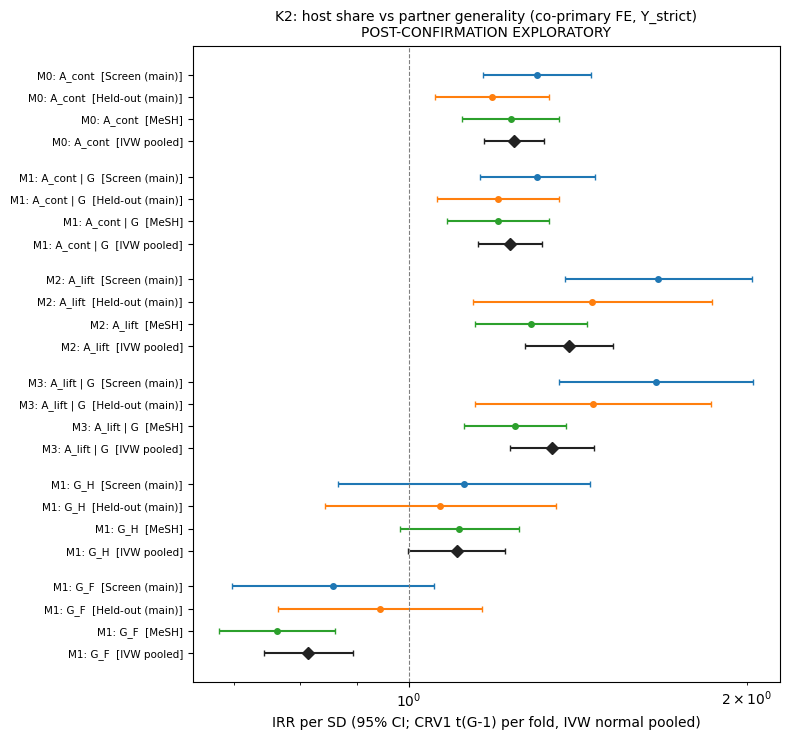

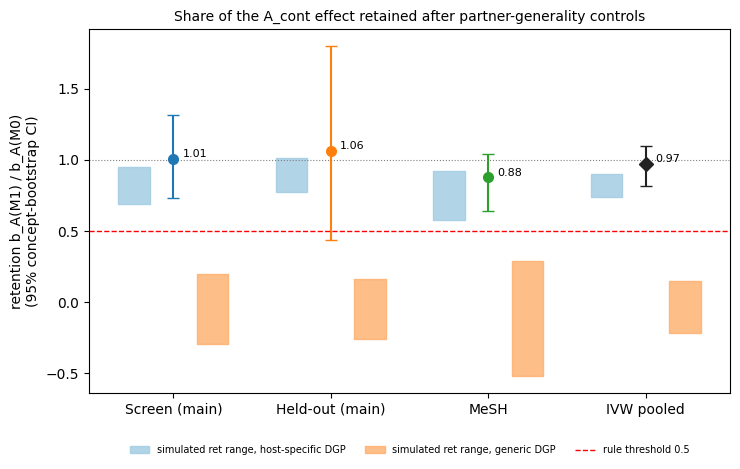

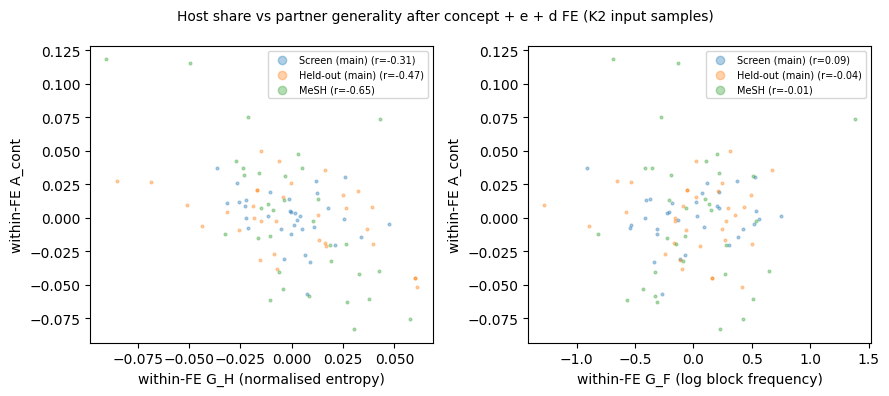

04:07:10|INFO   |figures written


04:07:10|INFO   |eval_out.json: 297 metrics; datasets [('k2_rows', 123), ('entry_generality', 99)]


In [12]:
@logger.catch(reraise=True)
def main() -> None:
    summ = data["k2_summary"]          # original: results/k2_summary.json
    power = data["k2_power"]           # original: results/k2_power.json
    plc = data["k2_placebo_host"]      # original: results/k2_placebo_host.json
    aud = data["audit_k2"]             # original: audit/audit_k2.json
    gates = data["gates"]              # original: results/gates.json
    desc = data["k2_descriptives"]     # original: results/k2_descriptives.json
    rows = pd.DataFrame(data["k2_rows"])  # original: pd.read_csv(RES / "k2_rows.csv")
    pg = pd.DataFrame(data["partner_generality"])  # original: pd.read_parquet(RES / "partner_generality.parquet")
    pg = pg.groupby("fold", sort=False).head(N_PG_PER_FOLD).reset_index(drop=True)  # demo: config-sized subset
    fig_forest(rows)
    fig_retention(summ, power)
    fig_scatter(pg)
    logger.info("figures written")
    out = {"metadata": {
        "evaluation_name": "K2 host-specific vs generic accessibility (POST-CONFIRMATION EXPLORATORY)",
        "spec_sha256": summ["spec_sha256"],
        "verdict_pooled": summ["pooled"]["verdict"], "qualifiers_pooled": summ["pooled"]["qualifiers"],
        "verdicts_folds": {f: summ["folds"][f]["verdict"] for f in FOLDS},
        "qualifiers_folds": {f: summ["folds"][f]["qualifiers"] for f in FOLDS},
        "verdict_coding": "k2_verdict_*: 1 HOST-SPECIFIC, 0 MIXED, -1 GENERIC ACCESSIBILITY",
        "decision_rule": data["k2_spec"]["decision_rule_verbatim"],  # original: results/k2_spec.json
        "sources": "results/k2_summary.json, results/k2_rows.csv, results/k2_power.json, "
                   "results/k2_placebo_host.json, audit/audit_k2.json, results/gates.json"},
        "metrics_agg": metrics(summ, power, plc, aud, gates, desc),
        "datasets": datasets(rows, pg)}
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1))
    logger.info(f"eval_out.json: {len(out['metrics_agg'])} metrics; datasets "
                f"{[(d['dataset'], len(d['examples'])) for d in out['datasets']]}")
    return out  # added so the results cell can inspect the output


out = main()

## Results summary
The table and chart below show the verdicts under the frozen rule, then retention and the lift IRR for each fold and for the pool.

**How to read them.** A pooled retention of about 0.97, with a CI of [0.81, 1.10], means the generality controls remove almost none of the `A_cont` effect. The M3 `A_lift` CI also lies above 1, so the verdict is **HOST-SPECIFIC**.

**Caveat.** `A_lift` is almost perfectly collinear with `ln A_cont` within the fixed effects (r ≈ 0.997). The lift leg of the rule therefore adds little independent evidence.

Spec sha256: 866c60a82ce4a5d3 …
Pooled verdict: HOST-SPECIFIC | qualifiers: none
           fold       verdict   ret b(M1)/b(M0) M3 A_lift|G IRR/SD  P(ret>=.5|host DGP)  P(ret<.5|generic DGP)
  Screen (main) HOST-SPECIFIC 1.01 [0.73, 1.31]  1.66 [1.36, 2.03]             1.000000                    1.0
Held-out (main) HOST-SPECIFIC 1.06 [0.44, 1.80]  1.46 [1.15, 1.86]             1.000000                    1.0
           MeSH HOST-SPECIFIC 0.88 [0.64, 1.04]  1.24 [1.12, 1.38]             0.993333                    1.0
     IVW pooled HOST-SPECIFIC 0.97 [0.81, 1.10]  1.34 [1.23, 1.46]             1.000000                    1.0

Pooled M1 generality controls (IRR/SD): G_H 1.10 [1.00, 1.22], G_F 0.81 [0.74, 0.89]
S10 placebo host passes under M1: {'screen': True, 'heldout': True, 'mesh': True}
S3 retention NATIVE vs ADJACENT: {'screen': (0.89, 1.01), 'heldout': (1.02, 1.01), 'mesh': (0.83, 1.1)}
Audit pass flags: {'a_entries': 1, 'b_pyfixest': 1, 'c_shuffled_G': 1, 'd_oracle_as_specifie

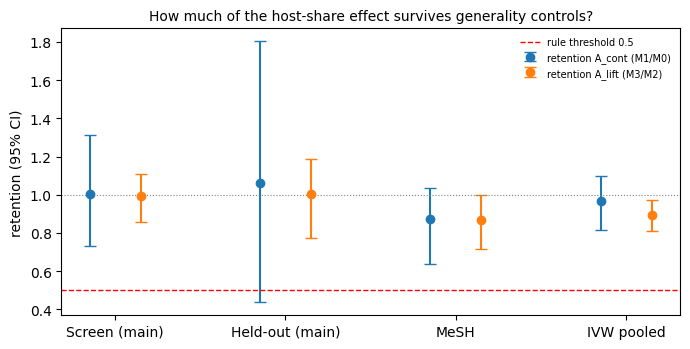

In [13]:
M = out["metrics_agg"]
meta = out["metadata"]
print("Spec sha256:", meta["spec_sha256"][:16], "…")
print("Pooled verdict:", meta["verdict_pooled"], "| qualifiers:", meta["qualifiers_pooled"] or "none")
tab = []
for f in FOLDS + ["pooled"]:
    tab.append({
        "fold": FNAME[f],
        "verdict": meta["verdict_pooled"] if f == "pooled" else meta["verdicts_folds"][f],
        "ret b(M1)/b(M0)": f'{M[f"k2_ret_{f}"]:.2f} [{M[f"k2_ret_{f}_lo"]:.2f}, {M[f"k2_ret_{f}_hi"]:.2f}]',
        "M3 A_lift|G IRR/SD": (f'{M["k2_pooled_M3_A_lift_irr_sd"]:.2f} [{M["k2_pooled_M3_A_lift_lo"]:.2f}, {M["k2_pooled_M3_A_lift_hi"]:.2f}]'
                               if f == "pooled" else
                               f'{M[f"k2_{f}_M3_A_lift_irr_sd"]:.2f} [{M[f"k2_{f}_M3_A_lift_irr_sd_lo"]:.2f}, {M[f"k2_{f}_M3_A_lift_irr_sd_hi"]:.2f}]'),
        "P(ret>=.5|host DGP)": M.get(f"k2_{f}_power_P_ret_ge05_DGP_S", M.get("k2_pooled_power_P_ret_ge05_DGP_S")),
        "P(ret<.5|generic DGP)": M.get(f"k2_{f}_power_P_ret_lt05_DGP_G", M.get("k2_pooled_power_P_ret_lt05_DGP_G")),
    })
print(pd.DataFrame(tab).to_string(index=False))

print("\nPooled M1 generality controls (IRR/SD): G_H %.2f [%.2f, %.2f], G_F %.2f [%.2f, %.2f]" % (
    M["k2_pooled_M1_G_H_irr_sd"], M["k2_pooled_M1_G_H_lo"], M["k2_pooled_M1_G_H_hi"],
    M["k2_pooled_M1_G_F_irr_sd"], M["k2_pooled_M1_G_F_lo"], M["k2_pooled_M1_G_F_hi"]))
print("S10 placebo host passes under M1:", {f: bool(M[f"k2_{f}_S10_placebo_M1_pass"]) for f in FOLDS})
print("S3 retention NATIVE vs ADJACENT:", {f: (round(M[f"k2_{f}_S3_ret_NAT"], 2), round(M[f"k2_{f}_S3_ret_ADJ"], 2)) for f in FOLDS})
print("Audit pass flags:", {k[9:-5]: int(v) for k, v in M.items() if k.startswith("k2_audit_") and k.endswith("_pass")})
print(f"\n{len(M)} metrics; datasets:", [(d["dataset"], len(d["examples"])) for d in out["datasets"]])

# Retention vs lift-retention per fold
fig, ax = plt.subplots(figsize=(7, 3.6))
keys = FOLDS + ["pooled"]
x = np.arange(len(keys))
for off, pre, lab, c in ((-0.15, "k2_ret_", "retention A_cont (M1/M0)", "#1f77b4"),
                         (0.15, "k2_ret_lift_", "retention A_lift (M3/M2)", "#ff7f0e")):
    v = np.array([M[f"{pre}{k}"] for k in keys])
    lo = np.array([M[f"{pre}{k}_lo"] for k in keys]); hi = np.array([M[f"{pre}{k}_hi"] for k in keys])
    ax.errorbar(x + off, v, yerr=[v - lo, hi - v], fmt="o", color=c, capsize=4, label=lab)
ax.axhline(0.5, color="red", ls="--", lw=1, label="rule threshold 0.5")
ax.axhline(1.0, color="grey", ls=":", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([FNAME[k] for k in keys])
ax.set_ylabel("retention (95% CI)")
ax.set_title("How much of the host-share effect survives generality controls?", fontsize=10)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout(); plt.show()